In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import objax
import bayesnewton
import xarray as xr
import time

Load 8x16 grid of z500 values, for 14 days training and 3 days testing data sampled hourly

In [6]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12.1', '2017.12.14'), lat=slice(0, None, 2), lon=slice(0, None, 4))['z']
z500_test= z500.sel(time=slice('2017.12.15', '2017.12.17'), lat=slice(0, None, 2), lon=slice(0, None, 4))['z']

In [7]:
data_mean = z500_train.mean(axis=0).load()
data_std = z500_train.std(axis=0).load()
data_train = (z500_train - data_mean) / data_std # normalise

t_train = (data_train.time - data_train.time[0]).values # time in hours
t_train = t_train / np.timedelta64(1, 'h') # convert to hours

In [8]:
from model import ExactMarkovGP

In [16]:
# Wrap arrays in format appropriate for the state space model
lat = jnp.array(data_train.lat)
lon = jnp.array(data_train.lon)
t_train = jnp.array(t_train)
z_train = jnp.array(data_train.values)
z_train.shape

LAT, LON = jnp.meshgrid(lat, lon, indexing='ij')
R = jnp.stack([LAT.ravel(), LON.ravel()], axis=-1)
R = jnp.repeat(R[None, ...], z_train.shape[0], axis=0)
Y = z_train.reshape(-1, 8*16)
t_train.shape, R.shape, Y.shape

((336,), (336, 128, 2), (336, 128))

In [34]:
# Initialise kernel hyperparameters
lengthscale_spatial = 0.2
lengthscale_temporal = 5.0
variance_spatial = 0.2
variance_temporal = 3.5

variance_noise = 1e-10 # Set very small to approximate no measurement noise

lik = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern32(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern32(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
gp = ExactMarkovGP(kernel, lik, X=t_train, R=R, Y=Y)

In [35]:
lr_adam = 0.5
epochs = 5

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: 6920.4427
epoch  2: loss: 345.9341
epoch  3: loss: -5614.4830
epoch  4: loss: -10641.0806
epoch  5: loss: -14070.2544
optimisation time: 35.03 secs


In [36]:
print(f"{'Initial temporal variance':<30} {variance_temporal:<5}     {'Learned temporal variance':<30} {gp.kernel.temporal_kernel.variance:.1f}")
print(f"{'Initial temporal lengthscale':<30} {lengthscale_temporal:<5}     {'Learned temporal lengthscale':<30} {gp.kernel.temporal_kernel.lengthscale:.1f}")
print()
print(f"{'Initial spatial variance':<30} {variance_spatial:<5}     {'Learned spatial variance':<30} {gp.kernel.spatial_kernel.variance:.1f}")
print(f"{'Initial spatial lengthscale':<30} {lengthscale_spatial:<5}     {'Learned spatial lengthscale':<30} {gp.kernel.spatial_kernel.lengthscale:.1f}")

Initial temporal variance      3.5       Learned temporal variance      1.3
Initial temporal lengthscale   5.0       Learned temporal lengthscale   7.5

Initial spatial variance       0.2       Learned spatial variance       0.2
Initial spatial lengthscale    0.2       Learned spatial lengthscale    0.2


In [37]:
# Normalize data_testsets
data_test = (z500_test - data_mean) / data_std

t_test = (data_test.time - data_train.time[0]).values
t_test = t_test / np.timedelta64(1, 'h')

In [38]:
train_mean, train_std = gp.predict(t_train)

In [39]:
test_mean, test_std = gp.predict(t_test)

In [40]:
train_mean = train_mean.reshape(-1, 8, 16)
train_std = train_std.reshape(-1, 8, 16)
test_mean = test_mean.reshape(-1, 8, 16)
test_std = test_std.reshape(-1, 8, 16)
data_train.shape, data_mean.shape, data_std.shape

((336, 8, 16), (8, 16), (8, 16))

In [41]:
def plot_std(x, y_mean, y_std, ax=None, **kwargs):
    if ax is None:
        fig, ax = plt.subplots()
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, **kwargs)

Text(0.5, 1.0, 'geopotential [lat=81.56, lon=0.00]')

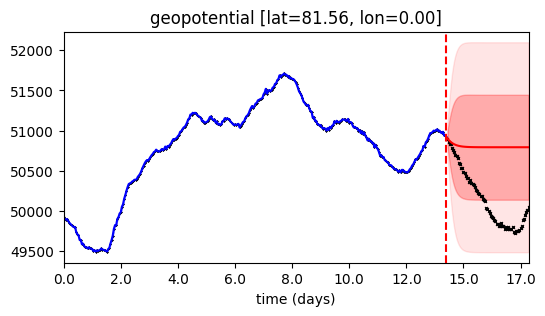

In [44]:
lat = 7
lon = 0
point = (slice(None),) + (lat, lon)

data_mean, data_std = np.array(data_mean), np.array(data_std)
fig, ax = plt.subplots(figsize=(6, 3))
# Train/test data
ax.plot(t_train, (data_mean + data_train * data_std)[point], color='black', marker='x', linestyle='none', ms=1)
ax.plot(t_test, (data_mean + data_test * data_std)[point], color='black', marker='x', linestyle='none', ms=2)

# Train/test predictions and uncertainties
ax.plot(t_train, (data_mean + train_mean * data_std)[point], color='blue')
ax.plot(t_test, (data_mean + test_mean * data_std)[point], color='red')
plot_std(t_train, (data_mean + train_mean * data_std)[point], (train_std * data_std)[point], ax=ax, color='blue', alpha=0.25)
plot_std(t_test, (data_mean + test_mean * data_std)[point], (test_std * data_std)[point], ax=ax, color='red', alpha=0.25)
plot_std(t_train, (data_mean + train_mean * data_std)[point], 2 * (train_std * data_std)[point], ax=ax, color='blue', alpha=0.1)
plot_std(t_test, (data_mean + test_mean * data_std)[point], 2 * (test_std * data_std)[point], ax=ax, color='red', alpha=0.1)

ax.axvline(t_train[-1], color='red', linestyle='--')
ax.set_xticks(ax.get_xticks(), np.around(ax.get_xticks()/24));
ax.margins(x=0)
ax.set_xlabel('time (days)')
title = 'geopotential [lat=%.2f, lon=%.2f]' % (data_train[point].lat, data_train[point].lon)
ax.set_title(title)

# Filter energy problems

```python
A_time = self.temporal_kernel.state_transition(dt)
A = np.kron(np.eye(self.M), A_time)
```